# 01 — Data Field Catalog

WorldQuant Brain exposes ~7,600 data fields per region/universe/delay combination
(USA / TOP3000 / delay=1 by default). This notebook downloads the catalog and
lets you explore what's available.

**First run:** takes 1–2 minutes to download. Results are cached to
`data/datafields.parquet` — subsequent runs load instantly.

**Key columns in the catalog:**
- `id` — field identifier used directly in alpha expressions (e.g. `close`, `volume`)
- `description` — human-readable description of what the field measures
- `category_name` — high-level group (e.g. `Fundamental`, `Price Volume`, `Model`)
- `dataset_name` — which Brain dataset provides the field
- `alphacount` — how many alphas on Brain use this field (higher = battle-tested)

In [1]:
import sys
from pathlib import Path
import pandas as pd

repo_root = Path.cwd().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [2]:
from wq.client import get_client, fetch_datafields

client = get_client()

Authenticated as jayesh.s@alumni.iitgn.ac.in


## Download the catalog

Fetches fields for USA / TOP3000 / delay=1 and saves to `data/datafields.parquet`.
To fetch a different region or universe, pass `region='CHN'` or `universe='TOP500'`.

In [3]:
fields_path = repo_root / 'data' / 'datafields.parquet'

if fields_path.exists():
    print(f'Loading from cache: {fields_path}')
    df = pd.read_parquet(fields_path)
else:
    print('Downloading catalog from Brain...')
    df = fetch_datafields(client, save=True)

print(f'\nTotal fields: {len(df):,}')
print(f'Columns: {list(df.columns)}')

Fetching 7,642 data fields from Brain...


100%|██████████| 7642/7642 [58:46<00:00,  2.17fields/s]  


Saved 7,642 fields → /Users/vishal.jsoni/PersonalProjects/WorldQuant-IQC-Alpha-Research/data/datafields.parquet

Total fields: 7,642
Columns: ['id', 'description', 'region', 'delay', 'universe', 'type', 'datecoverage', 'coverage', 'usercount', 'alphacount', 'themes', 'dataset_id', 'dataset_name', 'category_id', 'category_name', 'subcategory_id', 'subcategory_name']


## Field breakdown by category

In [4]:
# Use category_name for human-readable labels
cat_col = next(
    (c for c in df.columns if c.lower() == 'category_name'),
    next((c for c in df.columns if 'category' in c.lower() and 'sub' not in c.lower()), None)
)
if cat_col:
    category_counts = df[cat_col].value_counts()
    print(f'Fields by {cat_col}:')
    print(category_counts.to_string())
else:
    print('No category column found. Available columns:', df.columns.tolist())

Fields by category_name:
category_name
Model           3296
Fundamental     1652
Analyst         1324
News             996
Price Volume     195
Option           138
Social Media      22
Sentiment         19


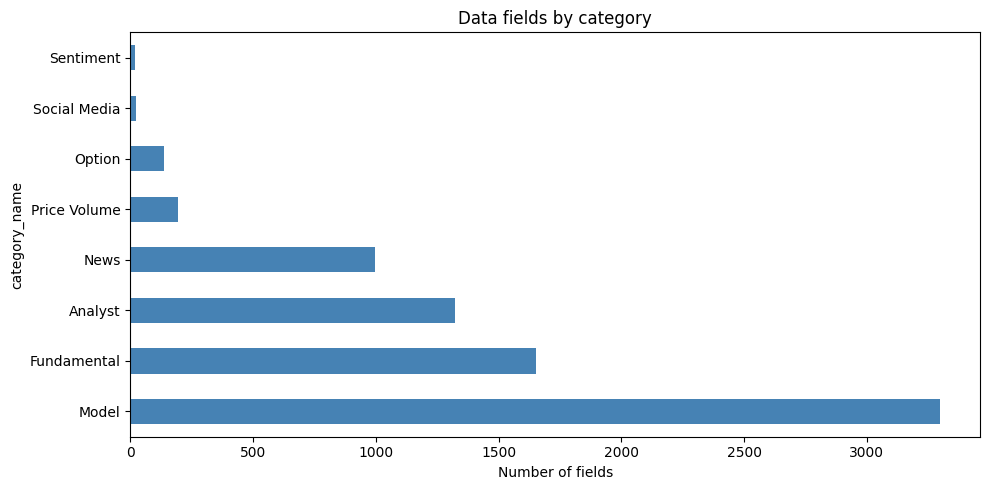

In [5]:
import matplotlib.pyplot as plt

if cat_col and len(category_counts) > 0:
    top_cats = category_counts.head(15)
    fig, ax = plt.subplots(figsize=(10, 5))
    top_cats.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title('Data fields by category')
    ax.set_xlabel('Number of fields')
    plt.tight_layout()
    plt.show()

## Search the catalog

Use `search_fields()` to find fields relevant to a research idea.
The `id` column is what you put in alpha expressions.

In [6]:
from wq.utils import search_fields

# Find fields related to earnings
results = search_fields(df, keyword='earnings')
print(f'Found {len(results)} fields matching "earnings"')
results[['id', 'description', 'category_name', 'alphacount']].head(20)

Found 1050 fields matching "earnings"


,id,description,category_name,alphacount
0,ebitda,Earnings Before Interest,Fundamental,20319
1,ebit,Earnings Before Interest and Taxes,Fundamental,19988
2,eps,Earnings Per Share (Basic) - Including Extraor...,Fundamental,16556
3,anl4_ebit_value,Earnings before interest and taxes - announced...,Analyst,15220
4,anl4_ebitda_value,"Earnings before interest, taxes, depreciation ...",Analyst,14531
5,anl4_epsr_flag,GAAP Earnings - estimation type (revision/new/...,Analyst,11765
6,anl4_qf_az_eps_number,Earnings per share - number of estimations,Analyst,10215
7,anl4_flag_erbfintax,Earnings before interest and taxes - forecast ...,Analyst,10164
8,retained_earnings,Retained Earnings,Fundamental,7427
9,est_eps,Earnings per share - mean of estimations,Analyst,7207


In [7]:
# Price/volume fields — most common for alpha construction
price_vol = search_fields(df, keyword='', category='price')
print(f'Price Volume fields: {len(price_vol)}')
price_vol[['id', 'description', 'alphacount']].head(20)

Price Volume fields: 0


,id,description,alphacount


In [8]:
# Fundamental fields
fundamental = search_fields(df, keyword='', category='fundamental')
print(f'Fundamental fields: {len(fundamental)}')
fundamental[['id', 'description', 'dataset_name', 'alphacount']].head(20)

Fundamental fields: 1652


,id,description,dataset_name,alphacount
0,assets,Assets - Total,Company Fundamental Data for Equity,147826
1,liabilities,Liabilities - Total,Company Fundamental Data for Equity,62652
2,operating_income,Operating Income After Depreciation - Quarterly,Company Fundamental Data for Equity,51233
3,enterprise_value,Enterprise Value,Company Fundamental Data for Equity,39787
4,sales,Sales/Turnover (Net),Company Fundamental Data for Equity,36130
5,debt,Debt,Company Fundamental Data for Equity,27906
6,capex,Capital Expenditures,Company Fundamental Data for Equity,27541
7,equity,Common/Ordinary Equity - Total,Company Fundamental Data for Equity,22496
8,ebitda,Earnings Before Interest,Company Fundamental Data for Equity,20319
9,ebit,Earnings Before Interest and Taxes,Company Fundamental Data for Equity,19988


## Most-used fields

Fields with high `alphacount` are used by many Brain researchers — good baselines.

In [9]:
count_col = next((c for c in df.columns if 'alphacount' in c.lower()), None)
if count_col:
    display_cols = [c for c in ['id', 'description', count_col, cat_col] if c and c in df.columns]
    top_used = df.nlargest(30, count_col)[display_cols]
    print('Top 30 most-used fields:')
    print(top_used.to_string(index=False))
else:
    print('alphacount column not found. Columns:', df.columns.tolist())

Top 30 most-used fields:
                        id                                                                                                                                                                                                                   description  alphacount category_name
                     close                                                                                                                                                                                                             Daily close price      546513  Price Volume
                       cap                                                                                                                                                                                     Daily market capitalization (in millions)      410049  Price Volume
                    sector                                                                                                                            

## Interactive field lookup

Change the keyword below and re-run to explore.

In [10]:
KEYWORD  = 'momentum'   # text to search in field id and description
CATEGORY = None         # e.g. 'fundamental', 'price', 'model', None for all

hits = search_fields(df, keyword=KEYWORD, category=CATEGORY)
print(f'{len(hits)} fields found')
hits[['id', 'description', 'category_name', 'alphacount']].head(30)

587 fields found


,id,description,category_name,alphacount
0,fscore_momentum,Composite momentum metric focused on recent an...,Model,489
1,mdl177_2_earningmomentumfactor400_q1aepsg,EPS growth estimate for next fiscal quarter,Model,438
2,fscore_surface,Static overall “style surface” score combining...,Model,434
3,analyst_revision_rank_derivative,Daily-indicator variant of momentum capturing ...,Model,418
4,mdl177_2_pricemomentumfactor_indrelrtn5d_,Stock's 5-day return minus industry average 5-...,Model,352
5,mdl177_fangma_emf_usa_fangma_emf25,Earnings momentum factors 25 for FANGMA (Faceb...,Model,351
6,mdl177_valuemomemtummodel_reportedearningsmome...,"Module tracking the momentum (trend, change, a...",Model,293
7,mdl177_earningmomentumfactor_q1aepsg_alt,Estimated growth in earnings per share for the...,Model,280
8,mdl177_earningmomentumfactor_qepsferr_alt,Forecast error for prior fiscal quarter’s earn...,Model,255
9,mdl177_valuemomemtummodel_vma_composite,Primary composite score combining value and mo...,Model,253
